# Table of Contents

- [Exploratory Data Analysis (EDA)](#Exploratory-Data-Analysis-(EDA))
- [Dataset Overview](#Dataset-Overview)
- [Missing Values](#Missing-Values)
- [Job Role Distribution](#Job-Role-Distribution)
- [Job Locations](#Job-Locations)
- [Salary Transparency Overview](#Salary-Transparency-Overview)

- [Research Question Analysis](#Research-Question-Analysis)

  - [Skills Demand](#Skills-Demand)
    - [Top 15 Most Requested Skills](#Top-15-Most-Requested-Skills)
    - [Skill Count Distribution by Role (Box Plot)](#Skill-Count-Distribution-by-Role-(Box-Plot))
    - [Top 10 Skills by Role (Heatmap)](#Top-10-Skills-by-Role-(Heatmap))

  - [Regional & Industry Differences](#Regional-&-Industry-Differences)
    - [Skill Requirements by Canton](#Skill-Requirements-by-Canton)
    - [Top 10 Skills by Industry (Heatmap)](#Top-10-Skills-by-Industry-(Heatmap))
    - [Role Distribution by Region](#Role-Distribution-by-Region)

  - [Seniority Differences](#Seniority-Differences)
    - [Top 10 Skills by Seniority Level (Heatmap)](#Top-10-Skills-by-Seniority-Level-(Heatmap))

  - [Workload Distribution](#Workload-Distribution)

  - [Macro Labor Market Context](#Macro-Labor-Market-Context)

  - [Salary Transparency Patterns](#Salary-Transparency-Patterns)

- [Summary of Findings](#Summary-of-Findings)
- [Data Limitations](#Data-Limitations)

# Exploratory Data Analysis (EDA)

This section explores the merged dataset containing Swiss job postings and macro-level vacancy statistics from the Swiss Federal Statistical Office (BFS). The objective is to understand the dataset structure, identify potential data quality issues, and explore key variables before addressing the research questions.

## Import Libraries 


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import ast

BG     = "#F8F9FB"
BLUE   = "#2C6E9E"
TEAL   = "#2CA4A0"
ORANGE = "#E07B39"
GREEN  = "#5BAD72"
PURPLE = "#7B5EA7"
COLORS = [BLUE, TEAL, ORANGE, GREEN, PURPLE, "#C94F6D", "#A0853C"]

sns.set(style="whitegrid")

## Load the Dataset

The dataset used in this analysis contains the merged job postings data (micro-level data) and macro labor market statistics obtained from BFS (macro-level data). The dataset is loaded from the processed data folder of the project repository.

In [22]:
df = pd.read_csv("../data/processed/jobs_merged_final.csv")
df.head()

,job_id,title,company,role,seniority,city,canton,region,posted_date,quarter,...,workload_max,salary_available,salary_min,salary_max,skills,skill_count,industry,macro_vacancies_region,macro_vacancies_industry,description
0,43725c60f2a0e7a20223831427ec1c5733c8e34c,Mission étudiante 40% : Data Analyst,Academic Work Switzerland,data scientist,NaN,Montreux,VD,Lake Geneva Region,2026-02-20,2026Q1,...,50.0,0,NaN,NaN,"['excel', 'power bi']",2,49-53 Transport and storage,13400.0,3746.0,About the job Tu es actuellement étudiant.e ? ...
1,929b4733c6e1c66d045413a3373023e435e25a0c,Junior Survey Data Analyst 20%,Academic Work Switzerland,data scientist,junior,Lausanne,VD,Lake Geneva Region,2026-02-10,2026Q1,...,20.0,0,NaN,NaN,['excel'],1,62-63 IT services,13400.0,3825.0,About the job Tu es étudiant.e et recherches u...
2,da46ba822882645bc160031dd473b01555e8e9c8,Merchandising & Data Analyst (H/F),Vilebrequin,data scientist,NaN,Plan-les-Ouates,GE,Lake Geneva Region,2026-02-06,2026Q1,...,100.0,0,NaN,NaN,['excel'],1,10-33 Manufacturing,13400.0,10980.0,"About the job Née en 1971 à St-Tropez, la mais..."
3,face52ba0e66311274a47f6df9fbf699abc6bc3d,Spécialiste informatique - Interfaces et donné...,Transports publics fribourgeois (TPF) SA,data scientist,NaN,Givisiez,FR,Espace Mittelland,2026-03-01,2026Q1,...,100.0,0,NaN,NaN,"['pandas', 'python', 'sql']",3,49-53 Transport and storage,14724.0,3746.0,About the job La mobilité est la raison d'être...
4,0e5906d2b6906c6f4eac077cdb6cda27d9955253,Data Scientist - Innovation Collaborations,EPFL,data scientist,NaN,Lausanne,VD,Lake Geneva Region,2026-02-20,2026Q1,...,100.0,0,NaN,NaN,"['artificial intelligence', 'machine learning']",2,85 Education,13400.0,2122.0,"About the job EPFL, the Swiss Federal Institut..."


## Dataset Overview 


This section provides a general overview of the dataset. It includes information about the number of observations, the number of variables, and the data types of each column. Understanding the structure of the dataset is an important first step before performing further analysis.

In [23]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (743, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 743 entries, 0 to 742
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   job_id                    743 non-null    object 
 1   title                     743 non-null    object 
 2   company                   743 non-null    object 
 3   role                      743 non-null    object 
 4   seniority                 349 non-null    object 
 5   city                      657 non-null    object 
 6   canton                    644 non-null    object 
 7   region                    644 non-null    object 
 8   posted_date               740 non-null    object 
 9   quarter                   743 non-null    object 
 10  macro_quarter             743 non-null    object 
 11  workload_min              723 non-null    float64
 12  workload_max              723 non-null    float64
 13  salary_available          743 non-null  

In [24]:
df.describe()

,workload_min,workload_max,salary_available,salary_min,salary_max,skill_count,macro_vacancies_region,macro_vacancies_industry
count,723.000000,723.000000,743.000000,9.000000,9.000000,743.000000,641.000000,740.000000
mean,93.326418,99.343015,0.012113,95777.777778,109666.666667,2.823688,16493.887676,6445.483784
std,12.820677,5.956087,0.109464,25183.217516,33387.872050,4.255313,4644.198276,4165.428528
min,5.000000,15.000000,0.000000,36000.000000,36000.000000,0.000000,1714.000000,2122.000000
25%,80.000000,100.000000,0.000000,88000.000000,88000.000000,0.000000,13400.000000,3825.000000
50%,100.000000,100.000000,0.000000,110000.000000,130000.000000,1.000000,14724.000000,3825.000000
75%,100.000000,100.000000,0.000000,110000.000000,130000.000000,4.000000,22114.000000,10980.000000
max,100.000000,100.000000,1.000000,115000.000000,135000.000000,46.000000,23842.000000,14561.000000


The descriptive statistics summarize key characteristics of the dataset. The average number of extracted skills per posting is 2.82, with a median of 1 skill, indicating that most job advertisements mention only a small set of explicitly identifiable technologies, while a few postings list many more skills (up to 46), resulting in a right-skewed distribution. Salary information is available in only a small fraction of postings (9 observations), with reported salaries ranging from CHF 36,000 to CHF 135,000. Workload requirements are typically close to full-time positions, with a median workload of 100%. The macro-level vacancy indicators show substantial regional and industry variation, suggesting differing labor market conditions across regions and sectors.

## Missing Values 

In this step, missing values are examined across all variables. Identifying missing data is important to understand potential limitations of the dataset and determine whether additional cleaning or adjustments may be required during analysis.

In [25]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

salary_min                  734
salary_max                  734
seniority                   394
macro_vacancies_region      102
canton                       99
region                       99
city                         86
workload_min                 20
workload_max                 20
macro_vacancies_industry      3
posted_date                   3
industry                      0
skill_count                   0
skills                        0
job_id                        0
salary_available              0
title                         0
macro_quarter                 0
quarter                       0
role                          0
company                       0
description                   0
dtype: int64

`salary_min`, `salary_max`, and `seniority` contain the most missing values. Salary is rarely disclosed in Swiss job ads. Seniority is not always stated explicitly in job titles. Regional nulls are due to unresolvable location strings in the raw data.

## Job Role Distribution 


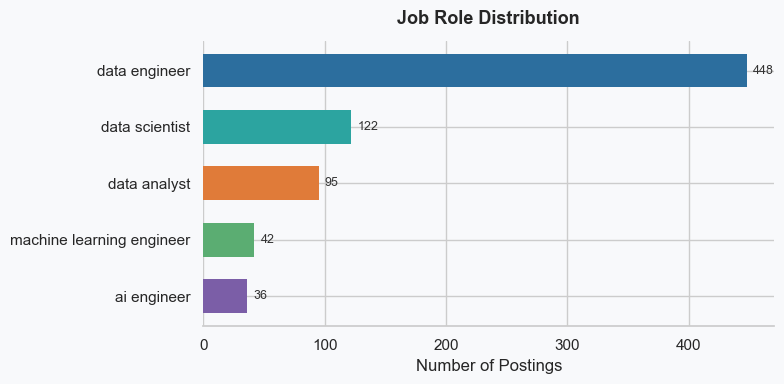

In [26]:
role_counts = df["role"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
ax.set_facecolor(BG)
bars = ax.barh(role_counts.index[::-1], role_counts.values[::-1],
               color=COLORS[:len(role_counts)][::-1], edgecolor="none", height=0.6)
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width())}", va='center', fontsize=9, color="#333")
ax.set_xlabel("Number of Postings")
ax.set_title("Job Role Distribution", fontsize=13, fontweight='bold', pad=12)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

Data Engineer is the most frequent role (448), followed by Data Scientist (122) and Data Analyst (95). ML Engineer and AI Engineer are more niche roles.

## Job Locations 


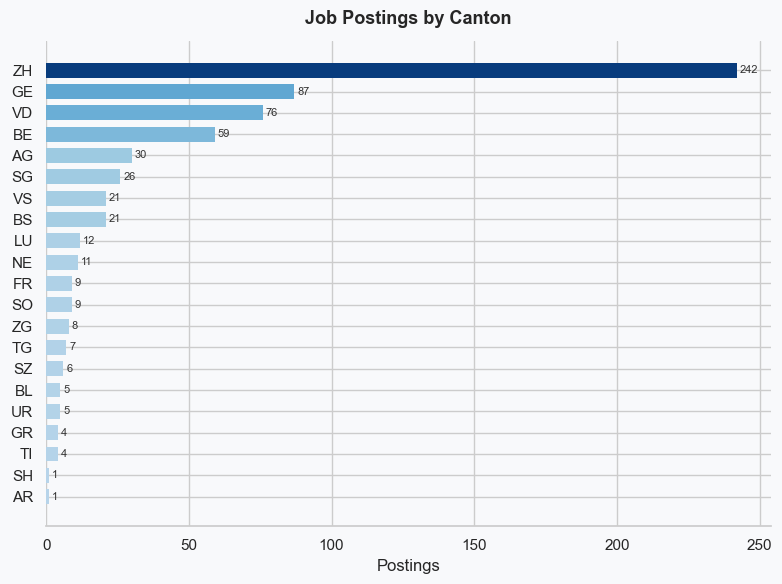

In [27]:
loc_counts = df["canton"].value_counts()
cmap = plt.cm.Blues
norm_vals = (loc_counts.values - loc_counts.values.min()) / (loc_counts.values.max() - loc_counts.values.min())
col = [cmap(0.3 + 0.65 * v) for v in norm_vals]

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
ax.set_facecolor(BG)
bars = ax.barh(loc_counts.index[::-1], loc_counts.values[::-1], color=col[::-1], edgecolor="none", height=0.7)
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width())}", va='center', fontsize=8, color="#333")
ax.set_xlabel("Postings")
ax.set_title("Job Postings by Canton", fontsize=13, fontweight='bold', pad=12)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

The distribution of job postings across cantons shows a strong concentration in major economic centers. Zurich clearly dominates the dataset with 242 postings, followed by Geneva (87) and Vaud (76). These cantons host many international companies, financial institutions, and technology firms, which likely explains the higher demand for data-related roles. Other cantons such as Bern (59) and Aargau (30) also show moderate activity, while most smaller cantons contribute only a limited number of postings. This uneven distribution highlights the geographic concentration of the Swiss data and technology labor market.

## Salary Transparency Overview 


In [28]:
salary_rate = df["salary_available"].mean()
print(f"Salary transparency rate: {round(salary_rate * 100, 2)} %")
print(f"Postings with salary: {df['salary_available'].sum()} / {len(df)}")

Salary transparency rate: 1.21 %
Postings with salary: 9 / 743


Salary information is provided in only **1.2% of job postings**, indicating extremely low salary transparency. Most employers omit compensation details and disclose them later in the recruitment process.

---
# Research Question Analysis

The following sections examine the three research questions from the feasibility study: skill demand, regional and industry differences, and salary transparency patterns.

## Skills Demand 

The first research question examines which skills are most frequently requested in Swiss data job postings.

### Helper: Parse Skills Column 


In [29]:
def parse_skills(x):
    try:
        return [s.strip().lower() for s in ast.literal_eval(x)]
    except:
        return []

df["skills_list"] = df["skills"].apply(parse_skills)
all_skills = [s for sl in df["skills_list"] for s in sl]
print(f"Total skill mentions: {len(all_skills)}")

Total skill mentions: 2098


### Top 15 Most Requested Skills 


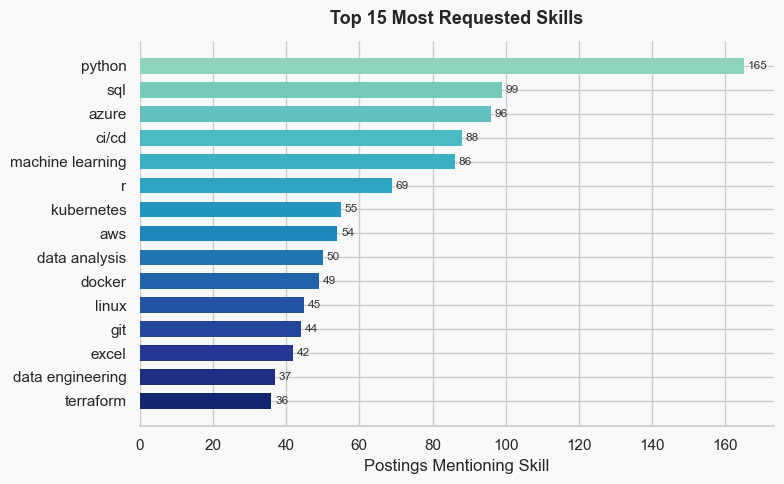

In [30]:
top15 = pd.DataFrame(Counter(all_skills).most_common(15), columns=["skill", "count"])

cmap2 = plt.colormaps["YlGnBu"]
cols = [cmap2(0.35 + 0.6 * (i / 14)) for i in range(15)]

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)
bars = ax.barh(top15["skill"][::-1], top15["count"][::-1],
               color=cols[::-1], edgecolor="none", height=0.65)
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width())}", va='center', fontsize=8.5, color="#333")
ax.set_xlabel("Postings Mentioning Skill")
ax.set_title("Top 15 Most Requested Skills", fontsize=13, fontweight='bold', pad=12)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

Python clearly dominates the skill landscape with 165 mentions, far exceeding all other technologies. SQL (99) and Azure (96) follow as the most frequently requested complementary skills, highlighting the importance of database management and cloud platforms in modern data roles. Infrastructure and deployment technologies such as CI/CD (88), Kubernetes (55), AWS (54), Docker (49), and Terraform (36) also appear frequently, indicating the growing relevance of MLOps and cloud-native workflows. Overall, the combination of programming languages, cloud platforms, and infrastructure tools reflects the increasingly interdisciplinary skill requirements of contemporary data and AI positions.

### Skill Count Distribution by Role 


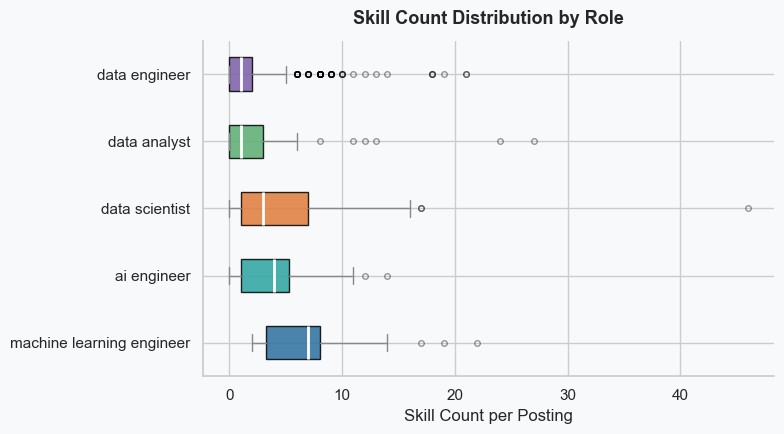

In [31]:
role_order = df.groupby("role")["skill_count"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(8, 4.5), facecolor=BG)
ax.set_facecolor(BG)
data_box = [df[df["role"] == r]["skill_count"].values for r in role_order]
bp = ax.boxplot(data_box, vert=False, patch_artist=True,
                medianprops=dict(color="white", linewidth=2),
                whiskerprops=dict(color="#888"),
                capprops=dict(color="#888"),
                flierprops=dict(marker='o', color="#888", alpha=0.4, markersize=4))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
ax.set_yticks(range(1, len(role_order) + 1))
ax.set_yticklabels(role_order)
ax.set_xlabel("Skill Count per Posting")
ax.set_title("Skill Count Distribution by Role", fontsize=13, fontweight='bold', pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Machine Learning Engineer postings exhibit the widest distribution of required skills, with several listings mentioning more than 15 technologies. Data Scientist and AI Engineer roles also show relatively broad skill ranges, reflecting the interdisciplinary nature of these positions. In contrast, Data Engineer postings tend to cluster at lower skill counts, while Data Analyst roles typically require a smaller and more focused set of technologies. Overall, the distribution suggests that engineering-oriented roles often demand broader technical stacks than analytical roles.

### Top 10 Skills by Role (Heatmap) 


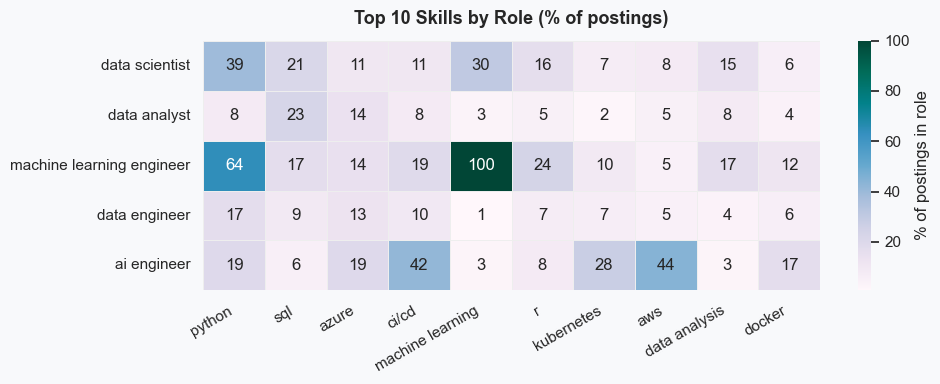

In [32]:
top10 = [s for s, _ in Counter(all_skills).most_common(10)]
roles = df["role"].unique()

rows_r = []
for role in roles:
    sub = df[df["role"] == role]
    all_s = [s for sl in sub["skills_list"] for s in sl]
    total = len(sub)
    rows_r.append({sk: all_s.count(sk) / max(total, 1) * 100 for sk in top10})

hm_role = pd.DataFrame(rows_r, index=roles)[top10]

fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
sns.heatmap(hm_role, ax=ax, cmap="PuBuGn", annot=True, fmt=".0f",
            linewidths=0.5, linecolor="#eee",
            cbar_kws={"label": "% of postings in role"})
ax.set_title("Top 10 Skills by Role (% of postings)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Python appears across all roles and is particularly dominant for Machine Learning Engineers and Data Scientists. Machine learning itself clearly distinguishes ML Engineer positions, where it appears in nearly all postings, and is also highly relevant for Data Scientists. In contrast, AI Engineer roles show stronger emphasis on deployment and infrastructure technologies such as CI/CD pipelines, Kubernetes, and cloud platforms like AWS, reflecting the operational nature of these positions.

## Regional & Industry Differences 

This section examines whether job requirements differ across regions and industries in Switzerland.

### Skill Requirements by Canton 


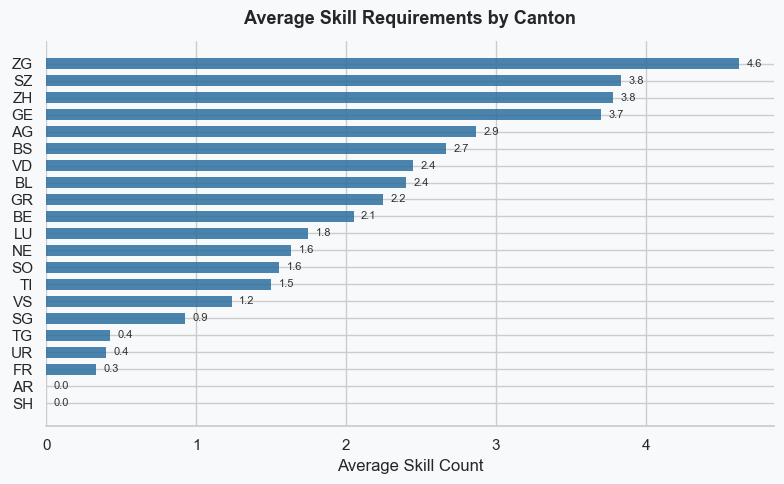

In [33]:
skills_canton = (
    df[df["canton"].notna()]
    .groupby("canton")["skill_count"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)
bars = ax.barh(skills_canton.index[::-1], skills_canton.values[::-1],
               color=BLUE, edgecolor="none", height=0.65, alpha=0.85)
for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.1f}", va='center', fontsize=8, color="#333")
ax.set_xlabel("Average Skill Count")
ax.set_title("Average Skill Requirements by Canton", fontsize=13, fontweight='bold', pad=12)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

The average number of required skills varies across cantons. Zug shows the highest average (4.6), followed by Schwyz, Zurich, and Geneva, where postings tend to list more technologies on average. These cantons are important economic centers and may host more complex or technical roles. However, results should be interpreted cautiously because some cantons have relatively few job postings, which can inflate average values. Overall, the pattern suggests that more economically active cantons tend to have slightly higher technical skill requirements in job postings.

### Top 10 Skills by Industry (Heatmap) 


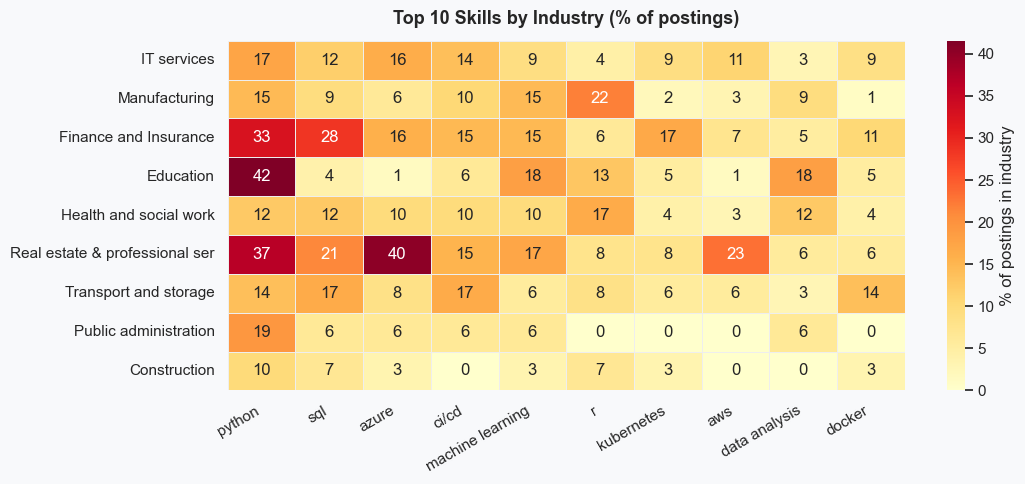

In [34]:
top_inds = df["industry"].value_counts()
top_inds = top_inds[top_inds >= 20].index.tolist()

rows_i = []
for ind in top_inds:
    sub = df[df["industry"] == ind]
    all_s = [s for sl in sub["skills_list"] for s in sl]
    total = len(sub)
    rows_i.append({sk: all_s.count(sk) / max(total, 1) * 100 for sk in top10})

hm_ind = pd.DataFrame(rows_i, index=[i.split(" ", 1)[-1][:30] for i in top_inds])[top10]

fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
sns.heatmap(hm_ind, ax=ax, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.5, linecolor="#eee",
            cbar_kws={"label": "% of postings in industry"})
ax.set_title("Top 10 Skills by Industry (% of postings)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The heatmap highlights notable differences in skill demand across industries. Python appears as the most consistently required skill across nearly all sectors, particularly in Education and Finance and Insurance. Cloud technologies such as Azure and AWS are especially prominent in Real Estate & Professional Services and Finance, reflecting the increasing reliance on cloud-based data infrastructures. Machine learning skills are more common in technology-oriented industries, while sectors such as Construction and Public Administration show relatively lower demand for advanced data technologies. Overall, the results indicate that industries differ substantially in their technical skill requirements, with technology-driven sectors demanding broader and more advanced skill sets.

### Role Distribution by Region 


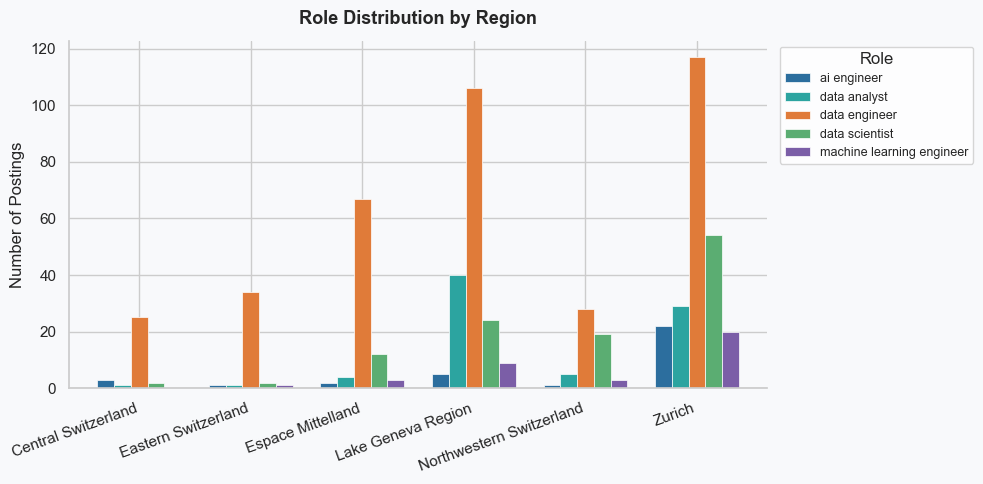

In [35]:
top_regions = df["region"].value_counts().head(6).index
rr = (df[df["region"].isin(top_regions)]
      .groupby(["region", "role"])
      .size()
      .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
ax.set_facecolor(BG)
rr.plot(kind='bar', ax=ax, color=COLORS[:len(rr.columns)], edgecolor="white", linewidth=0.5, width=0.75)
ax.set_xlabel("")
ax.set_ylabel("Number of Postings")
ax.set_title("Role Distribution by Region", fontsize=13, fontweight='bold', pad=12)
ax.legend(title="Role", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

The distribution of data-related roles varies considerably across regions. Zurich shows the highest number of postings across nearly all roles, particularly for Data Engineers and Data Scientists, highlighting its position as the main technology and financial hub in Switzerland. The Lake Geneva Region and Espace Mittelland also display substantial demand, especially for Data Engineers and Data Analysts. In contrast, regions such as Central and Eastern Switzerland show comparatively fewer postings across all roles. Overall, the results suggest a strong geographic concentration of data and AI jobs in major economic regions.

## Seniority Differences 

This section examines how skill requirements vary across seniority levels.

### Top 10 Skills by Seniority Level (Heatmap) 


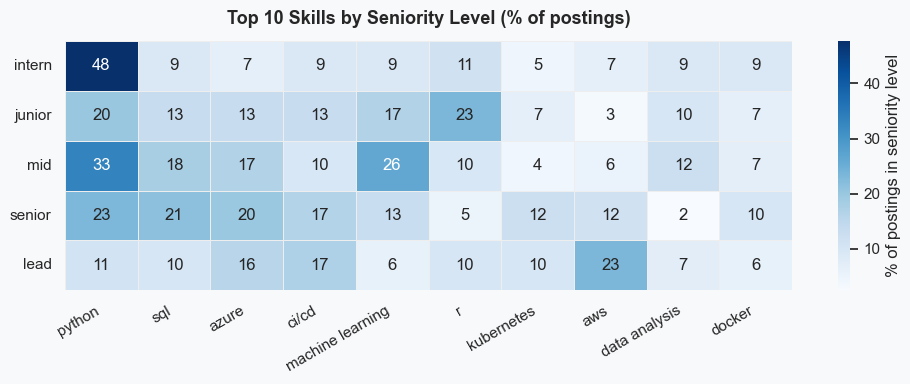

In [36]:
sen_order = ["intern", "junior", "mid", "senior", "lead"]
rows_s = []
for sen in sen_order:
    sub = df[df["seniority"] == sen]
    all_s = [s for sl in sub["skills_list"] for s in sl]
    total = len(sub)
    rows_s.append({sk: all_s.count(sk) / max(total, 1) * 100 for sk in top10})

hm_sen = pd.DataFrame(rows_s, index=sen_order)[top10]

fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
sns.heatmap(hm_sen, ax=ax, cmap="Blues", annot=True, fmt=".0f",
            linewidths=0.5, linecolor="#eee",
            cbar_kws={"label": "% of postings in seniority level"})
ax.set_title("Top 10 Skills by Seniority Level (% of postings)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The heatmap shows clear differences in skill requirements across seniority levels. Python is the most frequently mentioned skill at all levels, particularly in intern and mid-level positions. Junior and mid-level roles show stronger emphasis on machine learning and programming-related skills, reflecting the technical focus of these positions. In contrast, senior and lead roles increasingly require infrastructure and cloud-related technologies such as AWS, CI/CD, Kubernetes, and Docker, indicating a shift toward system architecture, deployment, and team-level responsibilities. Overall, the results suggest that technical depth dominates early-career roles, while leadership and system-level skills become more important at higher seniority levels.

## Workload Distribution by Role 


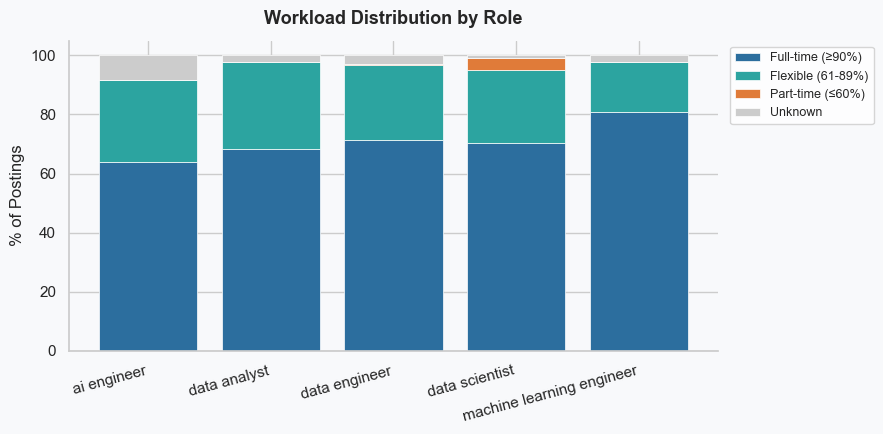

In [37]:
def workload_cat(row):
    if pd.isna(row["workload_min"]):
        return "Unknown"
    if row["workload_max"] <= 60:
        return "Part-time (≤60%)"
    if row["workload_min"] >= 90:
        return "Full-time (≥90%)"
    return "Flexible (61-89%)"

df["workload_cat"] = df.apply(workload_cat, axis=1)
wl = df.groupby(["role", "workload_cat"]).size().unstack(fill_value=0)
wl_pct = wl.div(wl.sum(axis=1), axis=0) * 100

wl_colors = {
    "Full-time (≥90%)":  BLUE,
    "Flexible (61-89%)": TEAL,
    "Part-time (≤60%)":  ORANGE,
    "Unknown":           "#ccc"
}

fig, ax = plt.subplots(figsize=(9, 4.5), facecolor=BG)
ax.set_facecolor(BG)
bottom = np.zeros(len(wl_pct))
for cat in ["Full-time (≥90%)", "Flexible (61-89%)", "Part-time (≤60%)", "Unknown"]:
    if cat in wl_pct.columns:
        vals = wl_pct[cat].values
        ax.bar(wl_pct.index, vals, bottom=bottom, label=cat,
               color=wl_colors[cat], edgecolor="white", linewidth=0.5)
        bottom += vals
ax.set_ylabel("% of Postings")
ax.set_title("Workload Distribution by Role", fontsize=13, fontweight='bold', pad=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

The workload distribution shows that most data-related roles are offered as full-time positions (≥90%), particularly for Machine Learning Engineers and Data Scientists. Flexible workloads (61–89%) also represent a notable share across all roles, indicating some degree of flexibility in working arrangements. Part-time positions (≤60%) are relatively rare and appear only marginally in the dataset. Overall, the results suggest that data and AI roles in Switzerland are predominantly structured as full-time positions, with limited availability of part-time opportunities.

## Macro Labor Market Context 

To validate the representativeness of the scraped data, job posting counts are compared with official BFS vacancy statistics at the regional level.

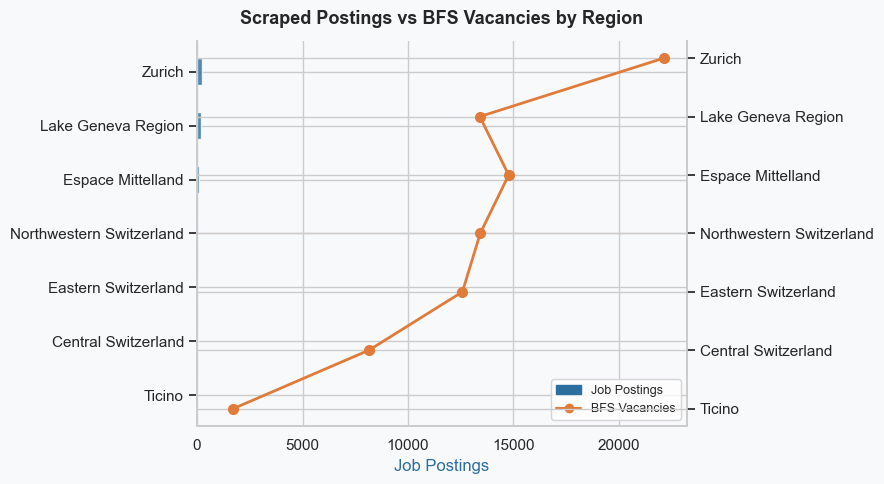

In [38]:
rc = (df[df["region"].notna()]
      .groupby("region")
      .agg(job_postings=("job_id", "count"),
           macro_vacancies=("macro_vacancies_region", "mean"))
      .reset_index()
      .sort_values("job_postings", ascending=True))

fig, ax1 = plt.subplots(figsize=(9, 5), facecolor=BG)
ax1.set_facecolor(BG)
ax2 = ax1.twinx()
ax1.barh(rc["region"], rc["job_postings"], color=BLUE, alpha=0.8, label="Job Postings", height=0.5)
ax2.plot(rc["macro_vacancies"], rc["region"], "o-", color=ORANGE,
         linewidth=2, markersize=7, label="BFS Vacancies")
ax1.set_xlabel("Job Postings", color=BLUE)
ax2.set_xlabel("BFS Macro Vacancies", color=ORANGE)
ax1.set_title("Scraped Postings vs BFS Vacancies by Region", fontsize=13, fontweight='bold', pad=12)
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)
h1 = mpatches.Patch(color=BLUE, label='Job Postings')
h2 = plt.Line2D([0], [0], color=ORANGE, marker='o', label='BFS Vacancies')
ax1.legend(handles=[h1, h2], loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

The comparison between scraped job postings and BFS vacancy statistics shows a broadly similar regional pattern. Zurich clearly stands out with the highest number of vacancies, followed by regions such as Espace Mittelland and the Lake Geneva Region. The scraped postings reflect this regional concentration, although the absolute numbers are much smaller than the BFS totals because the dataset only captures a subset of online job advertisements. Overall, the comparison suggests that the scraped data provides a reasonable proxy for regional labor market trends, even though it does not cover the full vacancy landscape.

## Salary Transparency Patterns 

The final research question examines whether salary transparency varies by canton and role.

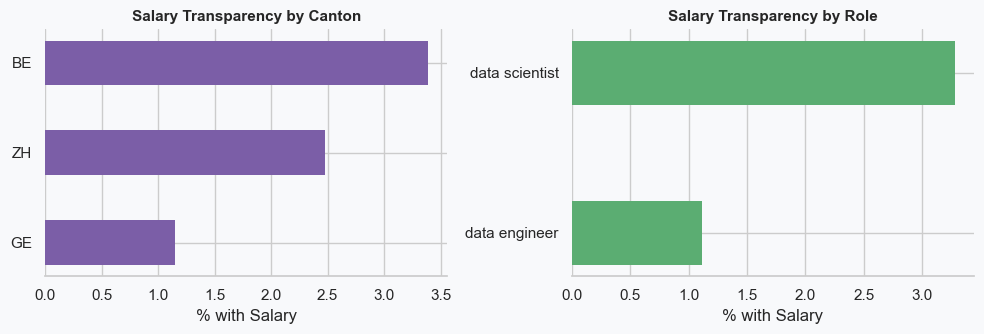

In [39]:
sal_c = (df[df["canton"].notna()]
         .groupby("canton")["salary_available"]
         .mean()
         .sort_values(ascending=False))
sal_c = sal_c[sal_c > 0]

sal_r = (df.groupby("role")["salary_available"]
         .mean()
         .sort_values(ascending=False))
sal_r = sal_r[sal_r > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5), facecolor=BG)
for ax in [ax1, ax2]:
    ax.set_facecolor(BG)

ax1.barh(sal_c.index[::-1], sal_c.values[::-1] * 100, color=PURPLE, edgecolor="none", height=0.5)
ax1.set_xlabel("% with Salary")
ax1.set_title("Salary Transparency by Canton", fontsize=11, fontweight='bold')
ax1.spines[['top', 'right', 'left']].set_visible(False)
ax1.tick_params(left=False)

ax2.barh(sal_r.index[::-1], sal_r.values[::-1] * 100, color=GREEN, edgecolor="none", height=0.4)
ax2.set_xlabel("% with Salary")
ax2.set_title("Salary Transparency by Role", fontsize=11, fontweight='bold')
ax2.spines[['top', 'right', 'left']].set_visible(False)
ax2.tick_params(left=False)

plt.tight_layout()
plt.show()

Salary transparency in the dataset is very limited across both cantons and roles. Only a small percentage of job postings include explicit salary information. Among the cantons, Bern shows the highest share of postings with salary data, followed by Zurich and Geneva, although the overall percentages remain very low. A similar pattern appears across roles, where Data Scientist postings display slightly higher salary transparency than Data Engineer positions. Overall, the results suggest that salary information is rarely disclosed in Swiss data-related job advertisements.

## Summary of Findings 

The analysis reveals several notable patterns in the Swiss data job market.

**Role demand:** Data Engineer emerges as the most frequently advertised role, followed by Data Scientist and Data Analyst. Machine Learning Engineer and AI Engineer positions appear less frequently, suggesting more specialized or emerging demand within the market.

**Skills:** Python, SQL, and Azure are the most commonly requested technologies across roles. The heatmap analysis highlights distinct skill profiles: infrastructure and deployment technologies such as CI/CD and Kubernetes are particularly associated with Data Engineering roles, while machine learning frameworks and R appear more frequently in Data Science and research-oriented positions.

**Regional concentration:** Job postings are strongly concentrated in major economic regions, particularly Zurich, Geneva, Vaud, and Bern. The regional distribution broadly mirrors BFS vacancy statistics, suggesting that the scraped dataset captures key spatial patterns of the Swiss labor market, even though it represents only a subset of total vacancies.

**Industry differences:** Technology-oriented sectors such as IT services and Finance display the highest technical skill requirements. These industries show strong demand for cloud platforms, data engineering tools, and DevOps-related technologies.

**Seniority:** Skill requirements vary across seniority levels. Entry-level and intern roles tend to emphasize specific analytical or programming tools, while senior and lead positions require a broader combination of technical and infrastructure-related skills.

**Salary transparency:** Salary transparency is extremely limited, with only about 1.2 of postings including explicit salary information. Only a few cantons, particularly Bern, Zurich, and Geneva, show any disclosure. This pattern itself constitutes an important finding, indicating that salary transparency is not yet a common practice in Swiss data-related job advertisements.

## Data Limitations 

Several limitations of the dataset should be considered when interpreting the results.

- **Location nulls (13.3%):** Some postings could not be mapped to a canton due to ambiguous or incomplete location strings (e.g., company names or broader regional labels). As a result, regional comparisons may be slightly affected.

- **Salary sparsity (98.8% null):** Only 9 of 743 postings include explicit salary information. Consequently, salary-related analyses should be interpreted as indicators of transparency rather than reliable estimates of market compensation levels.

- **Seniority nulls (53%):** Seniority classification is based on job title keywords. Many job titles do not explicitly indicate seniority level, which results in a substantial proportion of missing classifications.

- **Snapshot data:** All postings were collected within a short time window in early 2026. The findings therefore represent a snapshot of the market rather than long-term trends.

- **Skill extraction noise:** Approximately 38% of postings contain zero extracted skills. This partly reflects limitations of the keyword-based extraction approach and the inclusion of some non–data-science postings in the scrape. Skill analyses are therefore most informative for postings with `skill_count > 0`.